## 5.3 양자 네트워킹 (Quantum Networking)

In [1]:
from qiskit import QuantumCircuit, transpile  # 호환성 수정(qiskit 2.x): assemble 제거됨
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram
import matplotlib.pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 3큐비트 양자 회로 초기화
qc = QuantumCircuit(3)

In [3]:
# 1단계: Alice와 Bob의 큐비트 사이에 얽힘쌍(EPR 쌍) 생성
qc.h(0)      # 큐비트 0(Alice)에 하다마드
qc.cx(0, 1)  # 큐비트 0(Alice)과 큐비트 1(Bob) 얽기

In [4]:
# 2단계: Alice(큐비트 0)에서 Bob(큐비트 1)으로 양자 상태 순간이동
# Alice가 큐비트 2를 옮길 상태로 준비한다고 가정
qc.h(2)      # 큐비트 2(옮길 상태)에 하다마드
qc.cx(2, 0)  # 큐비트 2를 제어, 큐비트 0을 대상으로 CNOT
qc.h(2)      # 큐비트 2에 다시 하다마드

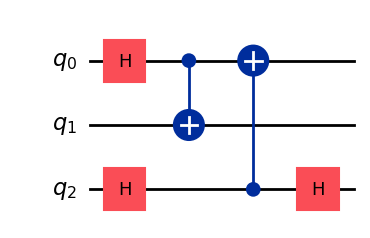

In [5]:
# 회로 그리기
qc.draw('mpl')
plt.show()

In [6]:
# 측정 전 회로를 트랜스파일·시뮬레이션해 상태 확인
simulator = AerSimulator()
qc_sim = transpile(qc, simulator)
result = simulator.run(qc_sim).result()

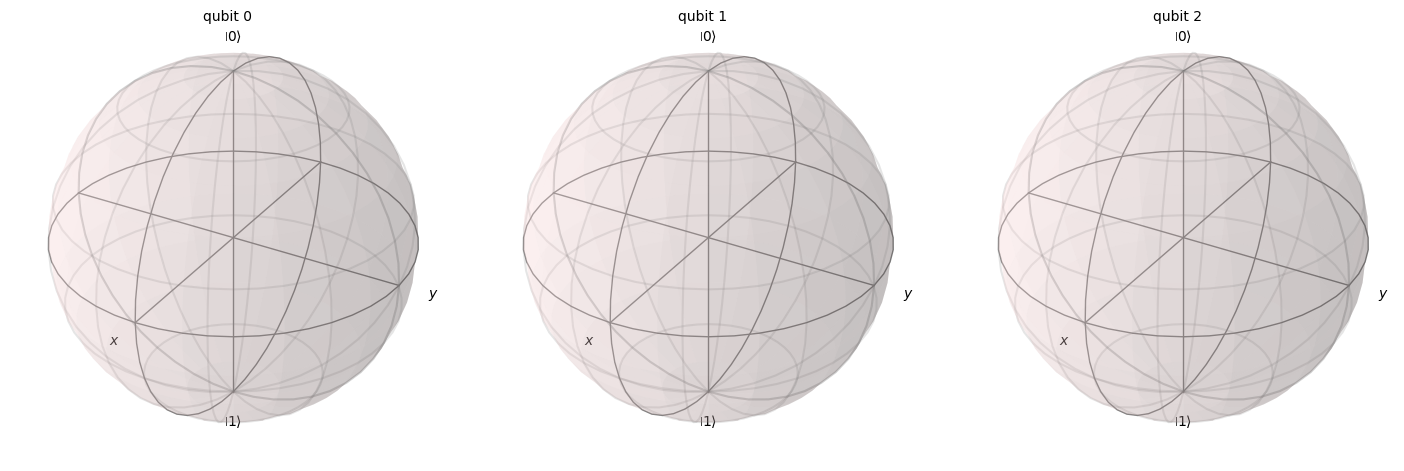

In [7]:
# 측정 전 상태벡터를 얻어 블로흐 구로 그리기
statevector = Statevector.from_instruction(qc)
plot_bloch_multivector(statevector)
plt.show()

In [8]:
# 3단계: Alice의 큐비트 측정
qc.measure_all()

In [9]:
# 4단계: 측정 후 회로를 시뮬레이션하고 결과 그리기
qc_sim = transpile(qc, simulator)
qobj = qc_sim  # 호환성 수정(qiskit 2.x): assemble 제거 → 트랜스파일된 회로를 그대로 사용
result = simulator.run(qobj).result()

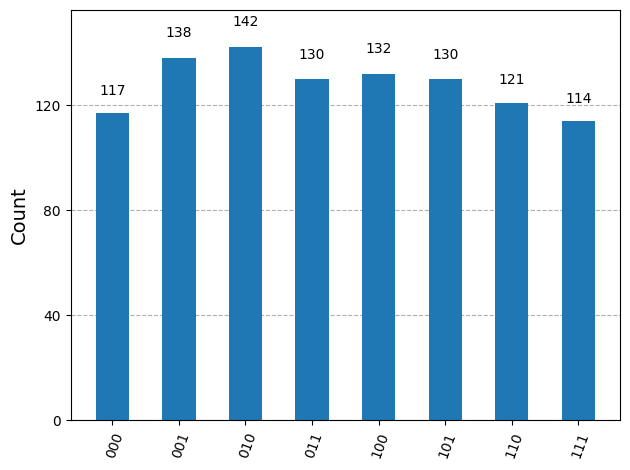

In [10]:
# 측정 결과 추출 및 그리기
counts = result.get_counts()
plot_histogram(counts)
plt.show()